# Week 3 Day 2: Activation Functions and Optimizers

Day 1 built a single linear neuron -- `w*X + b`, nothing else. That's a real limitation: stack as many linear neurons together as you want, the result is still just a straight line, since a linear function of a linear function is still linear. Activation functions are the fix: a small nonlinear twist applied to each neuron's output, which is what lets a network bend and curve to fit complex patterns instead of just drawing a line through data.

This notebook has three parts: implementing and visualizing the four activation functions by hand, proving the point concretely by teaching a small network to learn a curve (`y = x^2`) that a single linear neuron structurally cannot, and comparing plain gradient descent against the Adam optimizer on that same network.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

`x` is just a range of 100 test values -- not real data, just input to feed each activation function so we can see its shape.

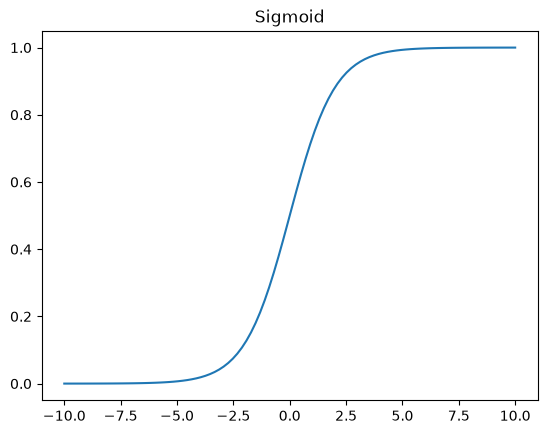

In [2]:
##starting with the sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

plt.plot(x, sigmoid(x))
plt.title("Sigmoid")
plt.show()

Sigmoid squashes any input into a value strictly between 0 and 1. Big positive numbers push toward 1, big negative numbers push toward 0, and 0 maps to exactly 0.5. As `x` grows large, `np.exp(-x)` shrinks toward 0, pushing the fraction toward `1/1 = 1`; as `x` goes very negative, `np.exp(-x)` explodes, pushing the fraction toward 0.

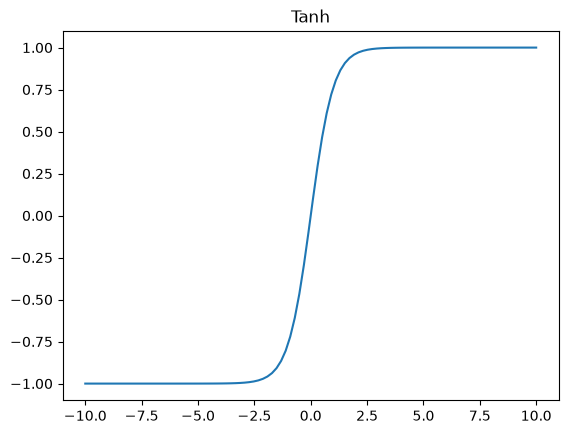

In [3]:
##tanh function
def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

plt.plot(x, tanh(x))
plt.title("Tanh")
plt.show()

Same general S-shape as Sigmoid, but squashed into a range of -1 to 1 instead of 0 to 1, and centered on 0 (`tanh(0) = 0`) rather than 0.5. Tanh and Sigmoid are actually mathematically related -- `tanh(x)` is just a rescaled, shifted version of Sigmoid.

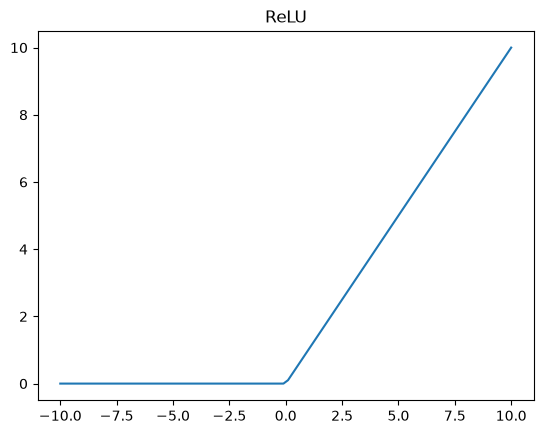

In [4]:
##ReLU function
def relu(x):
    return np.maximum(0, x)

plt.plot(x, relu(x))
plt.title("ReLU")
plt.show()

Much simpler than Sigmoid/Tanh: for any negative input, the output is exactly 0. For any positive input, the output is just the input, unchanged -- a flat line at 0 that kinks upward at 45 degrees once `x` crosses 0.

Despite being this simple, ReLU is the default choice for hidden layers in most modern deep learning. Look back at the Sigmoid and Tanh plots -- they flatten out almost completely once `x` gets far from 0 in either direction, meaning their slope there is nearly 0. Stack many layers of that and gradients shrink into practically nothing by the time they reach early layers (the "vanishing gradient" problem). ReLU's gradient is either exactly 0 or exactly 1, no matter how large the positive input gets -- nothing to vanish.

In [5]:
##softmax function scores
def softmax(scores):
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores)

class_scores = np.array([2.0, 1.0, 0.1])
probabilities = softmax(class_scores)
print("Raw scores:", class_scores)
print("Softmax probabilities:", probabilities)
print("Sum of probabilities:", np.sum(probabilities))

Raw scores: [2.  1.  0.1]
Softmax probabilities: [0.65900114 0.24243297 0.09856589]
Sum of probabilities: 1.0


Softmax works differently from the other three -- it doesn't act on one number at a time, it looks at a whole group of numbers together and converts them into a probability distribution. `class_scores` stands in for the raw, unbounded scores a network's final layer might produce for 3 competing classes. Softmax exponentiates each one (making everything positive, and amplifying differences), then divides each by the total, so everything sums to exactly 1 -- directly interpretable as "confidence per class," which is why Softmax specifically belongs on a network's output layer for multi-class problems, not hidden layers.

## Part 2: proving activation functions matter

Switching from a straight line (`y = 2x + 1`, Day 1) to a parabola (`y = x^2`) -- something a linear neuron structurally cannot learn, no matter how well it's trained. This is the real test of whether activation functions earn their keep.

In [6]:
##data testing
X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = X ** 2 ##switching from straight line to parabola for testing

`.reshape(-1, 1)` turns the flat list of 50 numbers into a column (50 rows, 1 column) -- needed for matrix multiplication once there are multiple hidden neurons, so NumPy knows these are 50 separate samples, each with 1 input feature.

In [7]:
##weights
np.random.seed(42)
hidden_size = 6 ##6 hidden neurons
W1 = np.random.randn(1, hidden_size) * 0.5
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, 1) * 0.5
b2 = 0.0

6 hidden neurons this time, not 1 -- each one learns to detect a different "piece" of the curve, and the output layer combines all 6 pieces together. `W1` is `(1, 6)`, `b1` is `(6,)`, `W2` is `(6, 1)`, `b2` is one number.

Important: why random weights instead of zero like Day 1? If every weight started at exactly 0, all 6 hidden neurons would receive identical input, compute identical output, and receive identical gradient updates during training -- forever. They'd never differentiate from each other. This didn't matter on Day 1 because there was only one neuron -- nothing to tell apart. With multiple neurons, randomness at the start is needed specifically to break that symmetry, so each one can specialize.

In [8]:
##forward pass steps using relu function
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1 ##multiplies the input data by the weights and adds the bias
    A1 = relu(Z1) ##activation function
    Z2 = A1 @ W2 + b2 ##combines the 6 activated values and returns final output as 1 number per sample
    return Z1, A1, Z2

Z1, A1, predictions = forward(X, W1, b1, W2, b2)
print("Predictions shape:", predictions.shape)
print("First 5 predictions:", predictions[:5].flatten())

Predictions shape: (50, 1)
First 5 predictions: [-0.0835849  -0.08017327 -0.07676165 -0.07335002 -0.06993839]


`X @ W1` gives `(50, 6)` -- for each of the 50 points, 6 different linear combinations, one per hidden neuron. `A1 = relu(Z1)` is where the activation actually does its job, zeroing out negative values -- the real "bend" that makes the network capable of more than a straight line. `A1 @ W2` combines those 6 activated values back into 1 prediction per sample. `Z1` and `A1` get returned (not just the prediction) because backpropagation needs those intermediate values to compute gradients later. Predictions are near-zero nonsense right now -- expected, since the network hasn't trained yet.

In [9]:
def compute_loss(predictions, y):
    return np.mean((predictions - y) ** 2)

loss = compute_loss(predictions, y)
print("Loss:", loss)

Loss: 15.566624158849963


Same MSE as Day 1. With predictions near 0 and true values ranging from 0 to 9, a large loss here is expected.

In [10]:
##backpropagation steps
def relu_derivative(x):
    return (x > 0).astype(float)

def backward(X, y, Z1, A1, predictions, W2):
    N = X.shape[0]

    dZ2 = (2 / N) * (predictions - y)  ##derivative of loss w.r.t predictions
    dW2 = A1.T @ dZ2  ##derivative of loss w.r.t W2
    db2 = np.sum(dZ2)  ##derivative of output w.r.t b2

    dA1 = dZ2 @ W2.T  ##derivative of loss w.r.t A1
    dZ1 = dA1 * relu_derivative(Z1)  ##derivative of loss w.r.t Z1
    dW1 = X.T @ dZ1  ##derivative of loss w.r.t W1
    db1 = np.sum(dZ1, axis=0)  ##derivative of loss w.r.t b1

    return dW1, db1, dW2, db2

The real core of today. `relu_derivative`: ReLU's slope is exactly 1 wherever `x > 0` and exactly 0 wherever `x < 0` -- `(x > 0).astype(float)` gives `1.0`/`0.0` accordingly.

`backward` is where the name "backpropagation" literally applies -- the error signal flows backward through the network, output to input:
- `dZ2` is the gradient of the loss w.r.t. the final prediction, same shape as Day 1's gradient, averaged over all 50 samples.
- `dW2`/`db2` are the output layer's gradients, same idea as Day 1's single neuron, using matrix multiplication to handle all 6 hidden neurons and 50 samples at once.
- `dA1 = dZ2 @ W2.T` is the actual backpropagation step -- it pushes the error backward through `W2` to figure out how much each hidden neuron contributed to it.
- `dZ1 = dA1 * relu_derivative(Z1)` is critical: it multiplies the backpropagated error by the ReLU derivative, which acts like a gate -- any hidden neuron that was "off" during the forward pass gets multiplied by 0 here, meaning no credit or blame for that example.
- `dW1`/`db1` are the input layer's gradients, same pattern one layer earlier.

In [11]:
##training loops
learning_rate = 0.01
epochs = 2000
losses = []
for epoch in range(epochs):
    Z1, A1, predictions = forward(X, W1, b1, W2, b2)
    loss = compute_loss(predictions, y)
    losses.append(loss)

    dW1, db1, dW2, db2 = backward(X, y, Z1, A1, predictions, W2)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: loss={loss:.4f}")

print(f"\nFinal loss: {losses[-1]:.4f}")

Epoch 0: loss=15.5666
Epoch 200: loss=0.4851
Epoch 400: loss=0.2618
Epoch 600: loss=0.1876
Epoch 800: loss=0.1359
Epoch 1000: loss=0.1070
Epoch 1200: loss=0.0870
Epoch 1400: loss=0.0763
Epoch 1600: loss=0.0705
Epoch 1800: loss=0.0670

Final loss: 0.0650


Same forward -> loss -> backward -> update structure as Day 1, just now updating 4 parameter groups instead of 2, over 2000 epochs instead of 1000 since fitting a curve with more coordinated parameters is a harder problem than fitting a line.

Loss dropped from 15.57 to 0.065 -- real learning, but notably it didn't reach near-zero the way Day 1's line-fit did. That's expected: a straight line could fit `y = 2x + 1` exactly, but a parabola can only ever be approximated by a finite number of ReLU pieces, no matter how long you train.

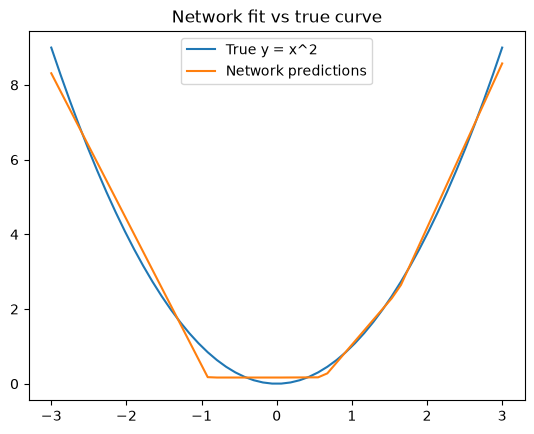

In [12]:
Z1, A1, final_predictions = forward(X, W1, b1, W2, b2)

plt.plot(X, y, label="True y = x^2")
plt.plot(X, final_predictions, label="Network predictions")
plt.legend()
plt.title("Network fit vs true curve")
plt.show() ##these rerun forward() one more time using the final trained weights and then plots on the same axes

The network's prediction is made of visible straight-line segments joined at a few sharp corners, not one smooth curve -- the direct visual signature of ReLU. Near the bottom of the parabola specifically, the true curve needs to smoothly dip to exactly 0 at x=0, but with only 6 hidden neurons (6 "kink points" to work with), the best straight-line approximation through that region ends up flatter than the true minimum. The sides fit well since the true curve is steep and roughly straight there anyway, which plays to ReLU's strengths. More hidden neurons would give more line segments to work with and hug the true curve more tightly, including a sharper dip at the bottom -- this is a direct demonstration of network *capacity*.

## Part 3: plain gradient descent vs. Adam

To fairly compare optimizers, the weights need to reset back to their original starting point -- otherwise Adam would be training on an already-trained network, not a fair test.

In [13]:
##optimizers
##Reset the weights to use Adam
np.random.seed(42)
W1 = np.random.randn(1, hidden_size) * 0.5
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, 1) * 0.5
b2 = 0.0

##storage
mW1, vW1 = np.zeros_like(W1), np.zeros_like(W1)
mb1, vb1 = np.zeros_like(b1), np.zeros_like(b1)
mW2, vW2 = np.zeros_like(W2), np.zeros_like(W2)
mb2, vb2 = 0.0, 0.0
beta1, beta2, epsilon = 0.9, 0.999, 1e-8

Unlike plain gradient descent (which just does `param -= learning_rate * gradient` using nothing but the current gradient), Adam keeps a running memory of past gradients for each parameter and uses that to adapt the step size individually. It tracks a moving average of the gradient itself (`m`, like momentum) and a moving average of the squared gradient (`v`, tracks how volatile that parameter's gradients tend to be). `np.zeros_like` creates matching all-zero starting storage. `beta1`/`beta2` control how much of the old running average to keep at each step (0.9 and 0.999 are the standard defaults), `epsilon` prevents ever dividing by zero later.

In [14]:
##Adam steps
def adam_update(param, grad, m ,v, t):
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * (grad ** 2)
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    param = param - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    return param, m, v

`m` blends 90% of the old running average with 10% of the newest gradient, smoothing out noisy directions over time. `v` does the same for the squared gradient, much more slowly (99.9% old, 0.1% new), building a sense of how large or volatile this parameter's gradients tend to be. `m_hat`/`v_hat` correct for the fact that both start at 0 and are artificially small early on -- as `t` grows this correction fades away naturally.

The actual update divides by `sqrt(v_hat)`: if a parameter's gradients have been large and wild, this shrinks its effective step (preventing overshoot); if they've been small and stable, this relatively boosts its step. Each parameter effectively gets its own personalized learning rate based on its own history, instead of every parameter being forced to use the same fixed step size.

One detail that matters: `t` can never be 0 here, since `1 - beta1**0 = 0` would be a division by zero -- the training loop below starts counting from `epoch = 1`, not 0.

In [15]:
adam_losses = []
for epoch in range(1, epochs + 1):
    Z1, A1, predictions = forward(X, W1, b1, W2, b2)
    loss = compute_loss(predictions, y)
    adam_losses.append(loss)

    dW1, db1, dW2, db2 = backward(X, y, Z1, A1, predictions, W2)

    W1, mW1, vW1 = adam_update(W1, dW1, mW1, vW1, epoch)
    b1, mb1, vb1 = adam_update(b1, db1, mb1, vb1, epoch)
    W2, mW2, vW2 = adam_update(W2, dW2, mW2, vW2, epoch)
    b2, mb2, vb2 = adam_update(b2, db2, mb2, vb2, epoch)

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: loss={loss:.4f}")
print(f"\nFinal Adam loss: {adam_losses[-1]:.4f}")

Epoch 200: loss=0.8164
Epoch 400: loss=0.1976
Epoch 600: loss=0.1036
Epoch 800: loss=0.0709
Epoch 1000: loss=0.0634
Epoch 1200: loss=0.0578
Epoch 1400: loss=0.0569
Epoch 1600: loss=0.0567
Epoch 1800: loss=0.0565
Epoch 2000: loss=0.0565

Final Adam loss: 0.0565


Adam finished at 0.0565 vs. plain gradient descent's 0.0650 -- a modest edge, but look at how it got there: Adam was already down to 0.0634 by epoch 1000 and barely moved after that, while plain gradient descent was still steadily inching down at epoch 1800-2000. Both level off around a similar floor, which lines up with what we already know -- 6 hidden neurons can only approximate the parabola so well, no matter which optimizer is used. That's a capacity limit, not an optimizer problem.

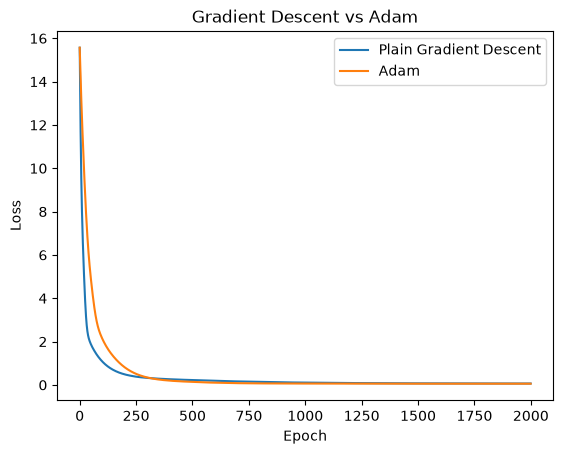

In [16]:
plt.plot(losses, label="Plain Gradient Descent")
plt.plot(adam_losses, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Descent vs Adam")
plt.legend()
plt.show()

Adam pulls ahead of plain gradient descent within the first ~100 epochs and reaches the low-loss floor faster. By the time both flatten out (roughly epoch 400-500 onward), they're visually overlapping since the actual gap is tiny on this scale.

## Takeaway

Two separate things got proven today. First, activation functions are what let a network learn anything beyond a straight line -- a hidden layer with ReLU learned a genuine curve, something Day 1's linear neuron could never do regardless of training. Second, the optimizer matters independently of the network architecture -- Adam's adaptive, per-parameter step sizing converged faster than plain gradient descent on the exact same network, same data, same starting weights. Neither one fixed the other's limitation, though: the network's approximation quality is capped by its hidden layer size (6 neurons), not by which optimizer trains it.